<img src="https://storage.googleapis.com/kaggle-datasets-images/3721736/6447201/86cc6d92471273c8c86f421a266ece65/dataset-cover.jpg?t=2023-09-11-17-38-22" width="1800">

<div style="border-radius: 10px; padding: 15px; background-color: #800000; font-size: 120%; text-align: left;">
<h2 align="left" style="color: #ffffff;">Recommendation System:</h2>

<font color="#ffffff">In summary, we aim to use the KMeans clustering algorithm to divide customers into 10 groups or clusters. Then, for each cluster, we will select the product with the highest purchase frequency as the top product. Finally, these top products will be recommended to customers who have not purchased them yet.
For example, if we form 10 clusters of customers, one top product will be identified for each cluster. Then, if there are customers within each cluster who have not bought this product, it will be suggested to them.
This approach helps you recommend similar products to your customers by combining the purchases of others. Through this method, you can achieve more effective sales and marketing strategies.</font>
</div>

<h1 style="color:black;font-size:40px;font-family:Georgia;text-align:center;">👩‍💻<strong>About DataSet </strong>👩‍💻</h1>
<center><a href="https://www.kaggle.com/datasets/samantas2020/online-retail-xlsx">Click here to know about data set</a></center> </p>

# Let's get started:

<a id="step1"></a>
# <p style="background-color:#515151; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 1 | Importing The Libraries</p>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.cluster import KMeans
import random

<a id="step2"></a>
# <p style="background-color:#515151; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 2 | Loading and Reading the Dataset</p>

In [ ]:
df = pd.read_excel('/kaggle/input/online-retail-xlsx/Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


<div style="border-radius: 10px; padding: 15px; background-color: #bebebe; font-size: 120%; text-align: left;">
<h2 align="left" style="color: #000000;">Exploring Dataset Information:</h2>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df = df[df['CustomerID'].notnull()]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


<a id="step3"></a>
# <p style="background-color:#515151; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 3 | Optimizing Data for Enhanced Clustering</p>

<div style="border-radius: 10px; padding: 15px; background-color: #bebebe; font-size: 120%; text-align: left;">
<h3 align="left" style="color: #000000;">"Creating 'InvoiceDay' Column for Date-Based Analysis":</h3>

<div style="border-radius: 10px; padding: 15px; background-color: #800000; font-size: 120%; text-align: left;">
<font color="#ffffff">
We did this to have the date of each invoice separately on a daily basis in our data. This change is significant because we may want to analyze the data based on different days or create groupings based on different days.In this way, having the  (`InvoiceDay`)  column allows us to perform more versatile time-based analyses on our data.
    </font>
    
</div>

In [ ]:
df['InvoiceDay'] = df['InvoiceDate'].apply(lambda x: dt.datetime(x.year, x.month, x.day))

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01


<div style="border-radius: 10px; padding: 15px; background-color: #bebebe; font-size: 120%; text-align: left;">
<h2 align="left" style="color: #000000;">"Finding Last Purchase Date for Customer Management":</h2>

<div style="border-radius: 10px; padding: 15px; background-color: #800000; font-size: 120%; text-align: left;">
<font color="#ffffff">
Now, we want to find the last purchase date of customers to perform proper clustering. This is because the date of the customers' last purchase can be a crucial point for applications or marketing strategies. Therefore, these codes are used for better customer management and planning, allowing us to cluster customers effectively based on their last purchase date.
    </font>
    
</div>

In [ ]:
dt.timedelta(1)

datetime.timedelta(days=1)

In [ ]:
pin_date = max(df['InvoiceDay']) + dt.timedelta(1)
pin_date

Timestamp('2011-12-10 00:00:00')

<div style="border-radius: 10px; padding: 15px; background-color: #bebebe; font-size: 120%; text-align: left;">
<h3 align="left" style="color: #000000;">"Creating 'TotalSum' Variable for Financial Analysis":</h3>

<div style="border-radius: 10px; padding: 15px; background-color: #800000; font-size: 120%; text-align: left;">

<font color="#ffffff">We have written this code to create a new variable called 'TotalSum.' This variable represents the total cost, calculated as the product of the quantity of each product and its unit price. By performing these calculations for each row in the dataframe, we can calculate the total cost of purchases for each customer.
The result of this process allows us to compute the total expenses for each customer, which can be utilized for financial analysis, generating reports, and data-driven decision-making. In other words, we have developed this code to establish a critical metric for enhanced financial analysis and customer financial management.</font>
</div>

In [ ]:
df['TotalSum'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,TotalSum
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,20.34


<div style="border-radius: 10px; padding: 15px; background-color: #bebebe; font-size: 120%; text-align: left;">
<h3 align="left" style="color: #000000;">Creating RFM Variables for Customer Analysis and Marketing Strategies:</h3>

<div style="border-radius: 10px; padding: 15px; background-color: #800000; font-size: 120%; text-align: left;">

<font color="#ffffff">

In summary, we wrote this code to create RFM (Recency, Frequency, Monetary) variables for each customer. These three variables hold significant importance in customer analysis and marketing strategies:

1. Recency (R): This variable indicates how much time has passed since the customer's last purchase. By calculating the number of days since the last purchase, we can assess how active customers are and whether they require further engagement or not.

2. Frequency (F): This variable represents the total number of purchases made by the customer. This information helps us identify customers with frequent purchases, enabling us to provide them with special discounts and offers.

3. Monetary (M): This variable showcases the total amount of money spent by each customer on purchases. It assists us in identifying customers with higher spending and designating them as valuable, high-potential customers.

Using this code, we can classify customers based on their recent activities, purchase frequency, and spending amounts. This classification enhances our decision-making in marketing and advertising strategies, allowing us to implement more effective customer-centric approaches.</font>
</div>

In [ ]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDay': lambda x: (pin_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalSum': 'sum'
})
rfm

,InvoiceDay,InvoiceNo,TotalSum
CustomerID,,,
12346.0,326,2,0.00
12347.0,3,182,4310.00
12348.0,76,31,1797.24
12349.0,19,73,1757.55
12350.0,311,17,334.40
...,...,...,...
18280.0,278,10,180.60
18281.0,181,7,80.82
18282.0,8,13,176.60


In [ ]:
rfm.rename(columns= {
    'InvoiceDay': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'Monetary'
}, inplace=True)
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,3,182,4310.00
12348.0,76,31,1797.24
12349.0,19,73,1757.55
12350.0,311,17,334.40
...,...,...,...
18280.0,278,10,180.60
18281.0,181,7,80.82
18282.0,8,13,176.60


<a id="step4"></a>
# <p style="background-color:#515151; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 4 | Data Preprocessing</p>

<div style="border-radius: 10px; padding: 15px; background-color: #800000; font-size: 120%; text-align: left;">

<font color="#ffffff">

In this section, we conducted a form of data preprocessing. First, we calculated the variables Recency, Frequency, and Monetary from the original data. Then, we transformed these calculated variables into different categories. This transformation depends on various label choices for each variable.

For instance, Recency is transformed into four categories, where each category represents a specific time interval from the last purchase made by the customer (with labels from 4 to 1, where 4 indicates closer proximity to the last purchase and 1 indicates a longer time span since the last purchase).

Frequency is also categorized into four groups, with each group indicating the total number of purchases made by the customer within a specified range (with labels from 1 to 4, where 1 represents the lowest number of purchases and 4 represents the highest).

Similarly, Monetary is divided into four categories, with each cluster representing the amount of money spent by the customer on their purchases (with labels from 1 to 4, where 1 indicates the lowest monetary value and 4 indicates the highest).

This categorization into groups helps us classify customers based on their performance in these three critical metrics (Recency, Frequency, Monetary). It enables us to implement marketing and customer-centric strategies more effectively.</font>
</div>

In [ ]:
r_labels = range(4, 0, -1) #[4, 3, 2, 1]
r_groups = pd.qcut(rfm['Recency'], q=4, labels=r_labels)
f_labels = range(1, 5) # [1, 2, 3, 4]
f_groups = pd.qcut(rfm['Frequency'], q=4, labels=f_labels)
m_labels = range(1, 5)
m_groups = pd.qcut(rfm['Monetary'], q=4, labels=m_labels)

In [ ]:
rfm['R'] = r_groups.values
rfm['F'] = f_groups.values
rfm['M'] = m_groups.values
rfm

,Recency,Frequency,Monetary,R,F,M
CustomerID,,,,,,
12346.0,326,2,0.00,1,1,1
12347.0,3,182,4310.00,4,4,4
12348.0,76,31,1797.24,2,2,4
12349.0,19,73,1757.55,3,3,4
12350.0,311,17,334.40,1,1,2
...,...,...,...,...,...,...
18280.0,278,10,180.60,1,1,1
18281.0,181,7,80.82,1,1,1
18282.0,8,13,176.60,4,1,1


<a id="step5"></a>
# <p style="background-color:#515151; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 5 | Customer Clustering for Targeted Marketing</p>

<div style="border-radius: 10px; padding: 15px; background-color: #800000; font-size: 120%; text-align: left;">

<font color="#ffffff">

In this code, we aimed to segment customers into 10 different clusters using the K-Means clustering algorithm. This allows us to categorize customers based on their behavior regarding recency, frequency, and monetary value. By grouping customers into clusters, we can implement different marketing and customer-centric strategies for each group, leading to more effective and personalized approaches.
</font>
</div>

In [ ]:
X = rfm[['R', 'F', 'M']]
kmeans = KMeans(n_clusters=10, init='k-means++', max_iter=300)
kmeans.fit(X)

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=10)

In [ ]:
kmeans.labels_

array([4, 9, 3, ..., 2, 9, 1], dtype=int32)

In [ ]:
rfm['kmeans_cluster'] = kmeans.labels_

In [ ]:
rfm

,Recency,Frequency,Monetary,R,F,M,kmeans_cluster
CustomerID,,,,,,,
12346.0,326,2,0.00,1,1,1,4
12347.0,3,182,4310.00,4,4,4,9
12348.0,76,31,1797.24,2,2,4,3
12349.0,19,73,1757.55,3,3,4,1
12350.0,311,17,334.40,1,1,2,0
...,...,...,...,...,...,...,...
18280.0,278,10,180.60,1,1,1,4
18281.0,181,7,80.82,1,1,1,4
18282.0,8,13,176.60,4,1,1,2


In [ ]:
rfm[rfm['kmeans_cluster'] == 0]

,Recency,Frequency,Monetary,R,F,M,kmeans_cluster
CustomerID,,,,,,,
12350.0,311,17,334.40,1,1,2,0
12355.0,215,13,459.40,1,1,2,0
12373.0,312,14,364.60,1,1,2,0
12386.0,338,10,401.90,1,1,2,0
12410.0,302,28,681.08,1,2,3,0
...,...,...,...,...,...,...,...
18194.0,65,9,896.00,2,1,3,0
18215.0,90,13,299.34,2,1,2,0
18220.0,220,4,297.78,1,1,2,0


<a id="step6"></a>
# <p style="background-color:#515151; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 6 | Customer Clustering Visualization</p>

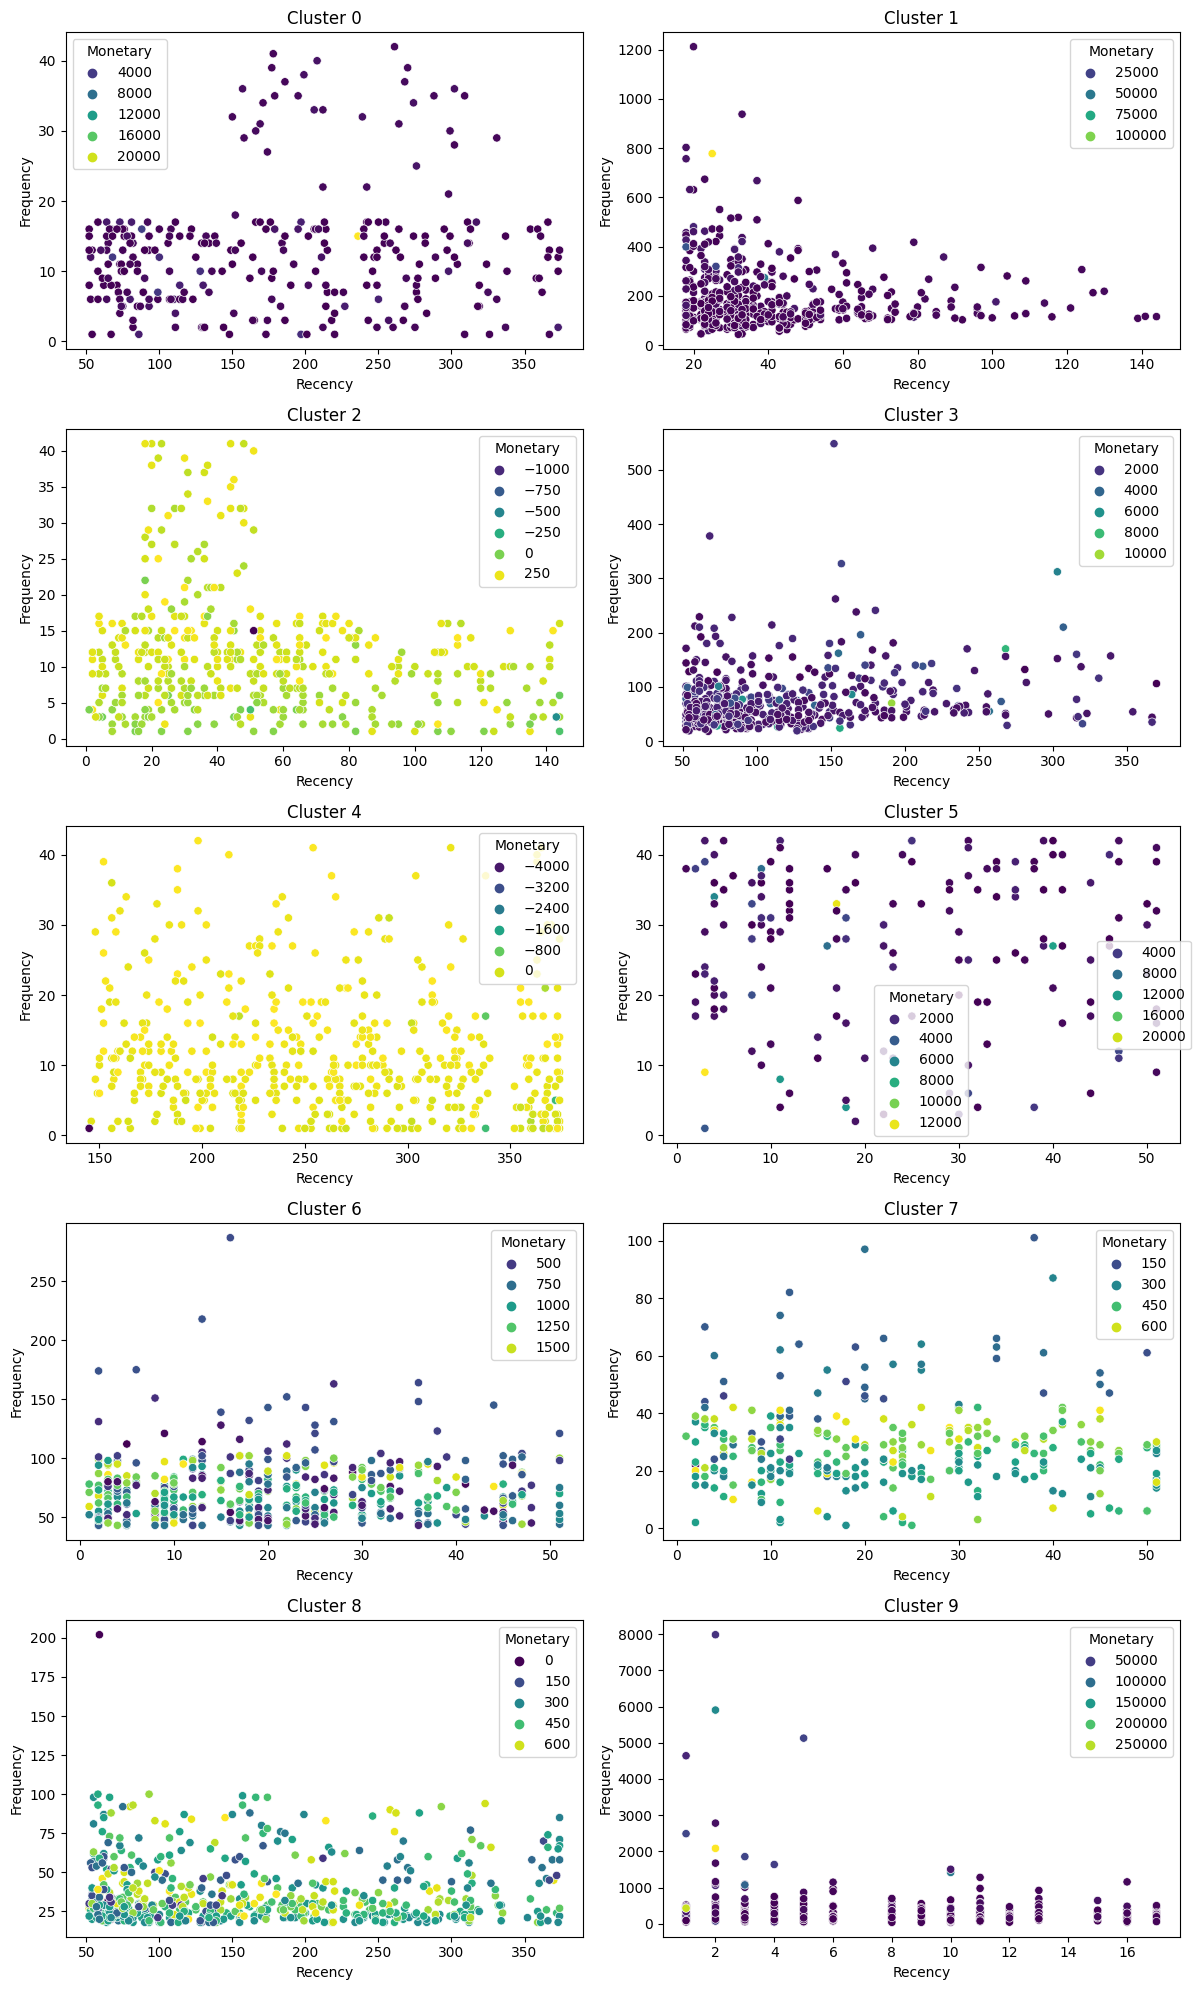

In [ ]:
# Number of clusters
num_clusters = 10

# Create subplots with two clusters in each row
fig, axes = plt.subplots(num_clusters // 2, 2, figsize=(12, 20))

# Flatten the axes array to iterate through subplots
axes = axes.ravel()

# Loop through each cluster and plot it
for cluster_id in range(num_clusters):
    # Filter data for the current cluster
    cluster_data = rfm[rfm['kmeans_cluster'] == cluster_id]

    # Plot the data with a distinct color
    sns.scatterplot(data=cluster_data, x='Recency', y='Frequency', hue='Monetary', palette='viridis', ax=axes[cluster_id])

    # Set the title for the subplot
    axes[cluster_id].set_title(f'Cluster {cluster_id}')

    # Customize axes labels, if needed
    # axes[cluster_id].set_xlabel('X-axis Label')
    # axes[cluster_id].set_ylabel('Y-axis Label')

# Add a common legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right')

# Adjust subplot spacing
plt.tight_layout()

# Show the plot
plt.show()


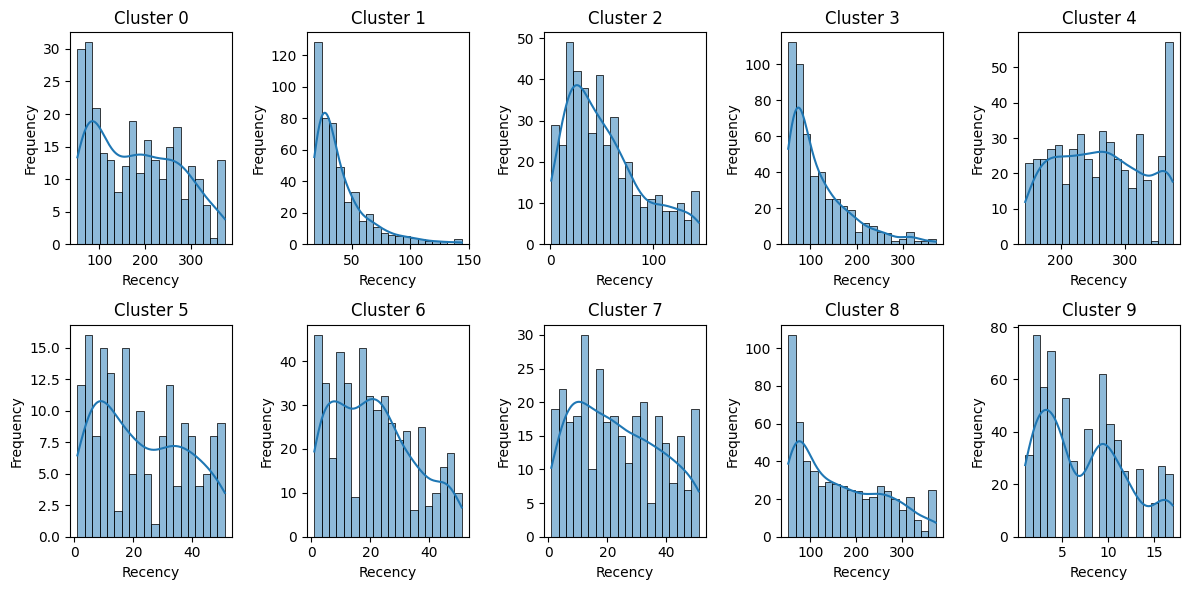

In [ ]:
# Create a histogram for Recency in each cluster
plt.figure(figsize=(12, 6))
for cluster_id in range(num_clusters):
    plt.subplot(2, 5, cluster_id + 1)
    sns.histplot(rfm[rfm['kmeans_cluster'] == cluster_id]['Recency'], bins=20, kde=True)
    plt.title(f'Cluster {cluster_id}')
    plt.xlabel('Recency')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


<a id="step7"></a>
# <p style="background-color:#515151; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 7 | Creating a Recommendation System</p>

<div style="border-radius: 10px; padding: 15px; background-color: #bebebe; font-size: 120%; text-align: left;">
<h3 align="left" style="color: #000000;">Generating Top Product Recommendations for Each Cluster</h3>

In [ ]:
# Number of clusters (groups)
num_clusters = 10

# Create an empty dictionary to store recommendations for each cluster
cluster_recommendations = {}

# Loop through each cluster
for cluster_id in range(num_clusters):
    # Find customers in the current cluster
    customers_in_cluster = rfm[rfm['kmeans_cluster'] == cluster_id].index

    # Find top products for customers in the current cluster
    top_products_for_cluster = df[df['CustomerID'].isin(customers_in_cluster)].groupby(['StockCode'])['InvoiceNo'].count().sort_values(ascending=False).head(10)

    # Store the top products for the current cluster in the dictionary
    cluster_recommendations[f'Cluster {cluster_id}'] = top_products_for_cluster.index.tolist()

# Display the recommendations for each cluster
for cluster, recommended_products in cluster_recommendations.items():
    print(f"{cluster} -> Recommended Products: {recommended_products}")


Cluster 0 -> Recommended Products: [47566, '85123A', 22423, 84879, '85099B', 22699, 22697, 22720, 'POST', 22178]
Cluster 1 -> Recommended Products: [22423, '85123A', '85099B', 20725, 84879, 47566, 22383, 23203, 23209, 22720]
Cluster 2 -> Recommended Products: [21034, 84946, 84879, 22577, 'POST', 23084, 22138, 22487, 22423, 'M']
Cluster 3 -> Recommended Products: ['85123A', 22423, 84879, 47566, 22720, 22960, 'POST', '85099B', 21212, 22457]
Cluster 4 -> Recommended Products: ['85123A', 22423, 21034, 47566, 22457, 22138, 'POST', 84879, 'M', 22427]
Cluster 5 -> Recommended Products: ['POST', 23084, '85123A', 23355, 22086, 84879, 47566, '85099B', 22423, 84946]
Cluster 6 -> Recommended Products: [22086, 22423, '85123A', 21034, 'POST', 23084, 84879, 22469, 22138, 22112]
Cluster 7 -> Recommended Products: [84879, 22086, 'POST', 22423, 22138, 21034, 23084, '85123A', 21790, 23355]
Cluster 8 -> Recommended Products: ['85123A', 22423, 47566, 21034, 22720, 22960, 22470, 84879, 'POST', 22138]
Cluste

<div style="border-radius: 10px; padding: 15px; background-color: #bebebe; font-size: 120%; text-align: left;">
<h3 align="left" style="color: #000000;">Cluster Analysis: Product Recommendations </h3>

In [ ]:
def generate_cluster_recommendations(num_clusters, num_customers_to_display, rfm, df):
    # Create an empty dictionary to store recommendations for each cluster
    cluster_recommendations = {}

    # Loop through each cluster
    for cluster_id in range(num_clusters):
        # Find customers in the current cluster
        customers_in_cluster = rfm[rfm['kmeans_cluster'] == cluster_id].index

        # Find top products for customers in the current cluster
        top_products_for_cluster = df[df['CustomerID'].isin(customers_in_cluster)].groupby(['StockCode'])['InvoiceNo'].count().sort_values(ascending=False).head(10)

        # Find customers who haven't purchased any of the top products in the current cluster
        non_buyers = [customer for customer in customers_in_cluster if not (df[(df['CustomerID'] == customer) & (df['StockCode'].isin(top_products_for_cluster.index.tolist()))]).empty]


        # Limit the number of non-buyers to the specified number
        num_customers_to_display = min(num_customers_to_display, len(non_buyers))

        # Select non-buyer customers for the current cluster
        selected_customers = non_buyers[:num_customers_to_display]

        # Store the top products and selected non-buyer customers for the current cluster in the dictionary
        cluster_recommendations[f'Cluster {cluster_id}'] = {
            'Recommended Products': top_products_for_cluster.index.tolist(),
            'Selected Non-Buyer Customers': selected_customers
        }

    return cluster_recommendations

# Example usage:
num_clusters = 10
num_customers_to_display = 5

# Assuming you already have 'rfm' and 'df' dataframes
cluster_recommendations = generate_cluster_recommendations(num_clusters, num_customers_to_display, rfm, df)

# Display the recommendations and selected non-buyer customers for each cluster
for cluster, recommendations_and_customers in cluster_recommendations.items():
    print(f"{cluster} ->")
    print("Recommended Products:")
    for customer_id in recommendations_and_customers['Selected Non-Buyer Customers']:
        print(f"Customer: {customer_id} =====>>>> Recommended Products: {recommendations_and_customers['Recommended Products']}")
    print()


Cluster 0 ->
Recommended Products:
Customer: 12350.0 =====>>>> Recommended Products: [47566, '85123A', 22423, 84879, '85099B', 22699, 22697, 22720, 'POST', 22178]
Customer: 12355.0 =====>>>> Recommended Products: [47566, '85123A', 22423, 84879, '85099B', 22699, 22697, 22720, 'POST', 22178]
Customer: 12373.0 =====>>>> Recommended Products: [47566, '85123A', 22423, 84879, '85099B', 22699, 22697, 22720, 'POST', 22178]
Customer: 12410.0 =====>>>> Recommended Products: [47566, '85123A', 22423, 84879, '85099B', 22699, 22697, 22720, 'POST', 22178]
Customer: 12436.0 =====>>>> Recommended Products: [47566, '85123A', 22423, 84879, '85099B', 22699, 22697, 22720, 'POST', 22178]

Cluster 1 ->
Recommended Products:
Customer: 12349.0 =====>>>> Recommended Products: [22423, '85123A', '85099B', 20725, 84879, 47566, 22383, 23203, 23209, 22720]
Customer: 12356.0 =====>>>> Recommended Products: [22423, '85123A', '85099B', 20725, 84879, 47566, 22383, 23203, 23209, 22720]
Customer: 12357.0 =====>>>> Recomme